# HemaVision — Blood Cell Classification

Deep-learning classification of microscopic white blood-cell images into:

- Eosinophil
- Lymphocyte
- Monocyte
- Neutrophil

Model: EfficientNet-B0  
Framework: PyTorch  
Explainability: Grad-CAM

Dataset: Blood Cell Images by Paul Mooney, Kaggle  
https://www.kaggle.com/datasets/paultimothymooney/blood-cells

> Educational and research use only. This project is not intended for clinical diagnosis.

# Imports

In [3]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

# Reproducibility

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


# Check GPU

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


# Dataset paths

In [6]:
DATA_ROOT = Path(
    "../data/raw/dataset2-master/dataset2-master/images"
)

TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR = DATA_ROOT / "TEST"
TEST_SIMPLE_DIR = DATA_ROOT / "TEST_SIMPLE"

print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())
print("Test simple exists:", TEST_SIMPLE_DIR.exists())

Train exists: True
Test exists: True
Test simple exists: True


# Read class names

In [7]:
class_names = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

class_names

['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

# Count images

In [8]:
def count_images(directory):
    counts = {}

    for class_name in class_names:
        class_dir = directory / class_name

        images = list(class_dir.glob("*.jpeg"))
        counts[class_name] = len(images)

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("TRAIN:", train_counts)
print("TEST:", test_counts)

TRAIN: {'EOSINOPHIL': 2497, 'LYMPHOCYTE': 2483, 'MONOCYTE': 2478, 'NEUTROPHIL': 2499}
TEST: {'EOSINOPHIL': 623, 'LYMPHOCYTE': 620, 'MONOCYTE': 620, 'NEUTROPHIL': 624}


# Visualize class distribution

In [9]:
df_counts = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
})

df_counts

,Train,Test
EOSINOPHIL,2497,623
LYMPHOCYTE,2483,620
MONOCYTE,2478,620
NEUTROPHIL,2499,624


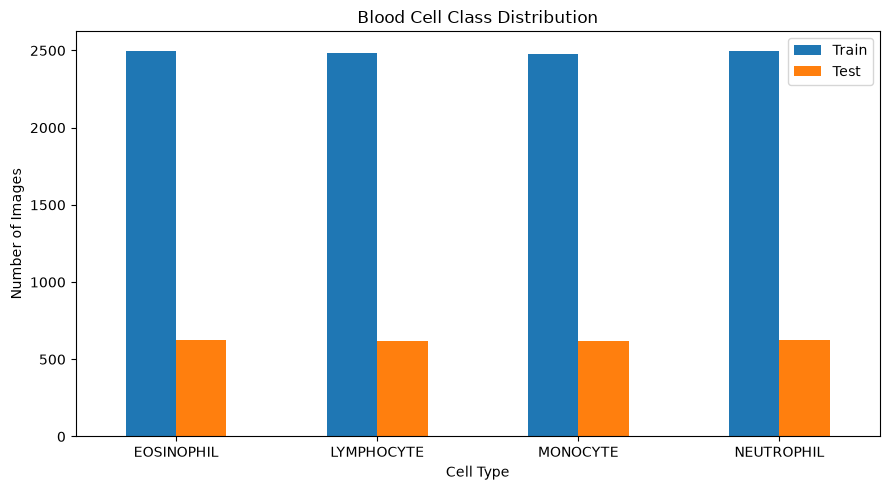

In [10]:
df_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Blood Cell Class Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Display microscope images

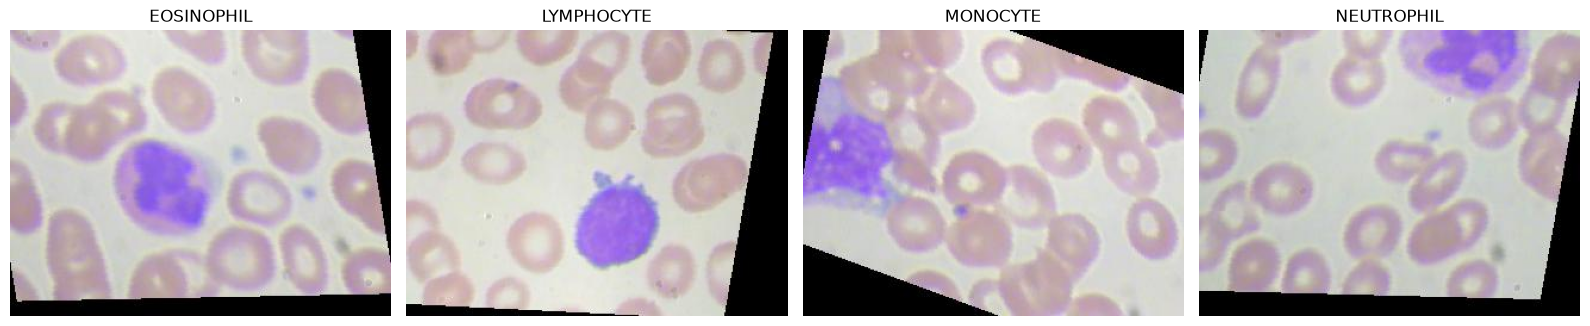

In [11]:
fig, axes = plt.subplots(
    1,
    len(class_names),
    figsize=(16, 4)
)

for ax, class_name in zip(axes, class_names):

    class_dir = TRAIN_DIR / class_name
    image_path = random.choice(list(class_dir.glob("*.jpeg")))

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Inspect image sizes

In [12]:
sizes = []

for class_name in class_names:

    paths = list(
        (TRAIN_DIR / class_name).glob("*.jpeg")
    )

    for path in paths[:100]:

        with Image.open(path) as img:
            sizes.append(img.size)

from collections import Counter

Counter(sizes).most_common(10)

[((320, 240), 400)]

# Define image preprocessing

In [13]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created.")

Transforms created.


# Create base dataset

In [14]:
from torchvision.datasets import ImageFolder

base_train_dataset = ImageFolder(
    root=TRAIN_DIR
)

print("Total training images:", len(base_train_dataset))
print("Classes:", base_train_dataset.classes)
print("Class mapping:", base_train_dataset.class_to_idx)

Total training images: 9957
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Class mapping: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


# Stratified train/validation split

In [15]:
targets = np.array(base_train_dataset.targets)

indices = np.arange(len(targets))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    stratify=targets
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))

Training images: 8463
Validation images: 1494


In [16]:
print(
    len(train_indices) + len(val_indices)
)

9957


# Verify stratification

In [17]:
from collections import Counter

train_labels = targets[train_indices]
val_labels = targets[val_indices]

print("Train distribution:")
print(Counter(train_labels))

print("\nValidation distribution:")
print(Counter(val_labels))

Train distribution:
Counter({np.int64(3): 2124, np.int64(0): 2122, np.int64(1): 2111, np.int64(2): 2106})

Validation distribution:
Counter({np.int64(0): 375, np.int64(3): 375, np.int64(1): 372, np.int64(2): 372})


In [18]:
idx_to_class = {
    value: key
    for key, value in base_train_dataset.class_to_idx.items()
}

print("\nTraining:")
for label, count in sorted(Counter(train_labels).items()):
    print(idx_to_class[label], count)

print("\nValidation:")
for label, count in sorted(Counter(val_labels).items()):
    print(idx_to_class[label], count)


Training:
EOSINOPHIL 2122
LYMPHOCYTE 2111
MONOCYTE 2106
NEUTROPHIL 2124

Validation:
EOSINOPHIL 375
LYMPHOCYTE 372
MONOCYTE 372
NEUTROPHIL 375


# Create separate datasets

In [19]:
train_full_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_full_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=val_test_transform
)

In [20]:
from torch.utils.data import Subset

train_dataset = Subset(
    train_full_dataset,
    train_indices
)

val_dataset = Subset(
    val_full_dataset,
    val_indices
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 8463
Validation: 1494


# Load the untouched test set

In [21]:
test_dataset = ImageFolder(
    root=TEST_DIR,
    transform=val_test_transform
)

print("Test images:", len(test_dataset))
print("Test classes:", test_dataset.classes)

Test images: 2487
Test classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


# Verify class mappings match

In [22]:
print(
    "Train mapping:",
    train_full_dataset.class_to_idx
)

print(
    "Test mapping:",
    test_dataset.class_to_idx
)

assert (
    train_full_dataset.class_to_idx
    ==
    test_dataset.class_to_idx
)

print("\nClass mappings match ✓")

Train mapping: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}
Test mapping: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}

Class mappings match ✓


# Create DataLoaders

In [23]:
BATCH_SIZE = 32

In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 265
Validation batches: 47
Test batches: 78


# Inspect one batch

In [25]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Labels: tensor([1, 1, 3, 0, 2, 3, 2, 0, 0, 2])


# Visualize augmented training images

In [26]:
mean = np.array(
    [0.485, 0.456, 0.406]
)

std = np.array(
    [0.229, 0.224, 0.225]
)


def denormalize(image):
    image = image.numpy().transpose((1, 2, 0))

    image = std * image + mean

    image = np.clip(
        image,
        0,
        1
    )

    return image

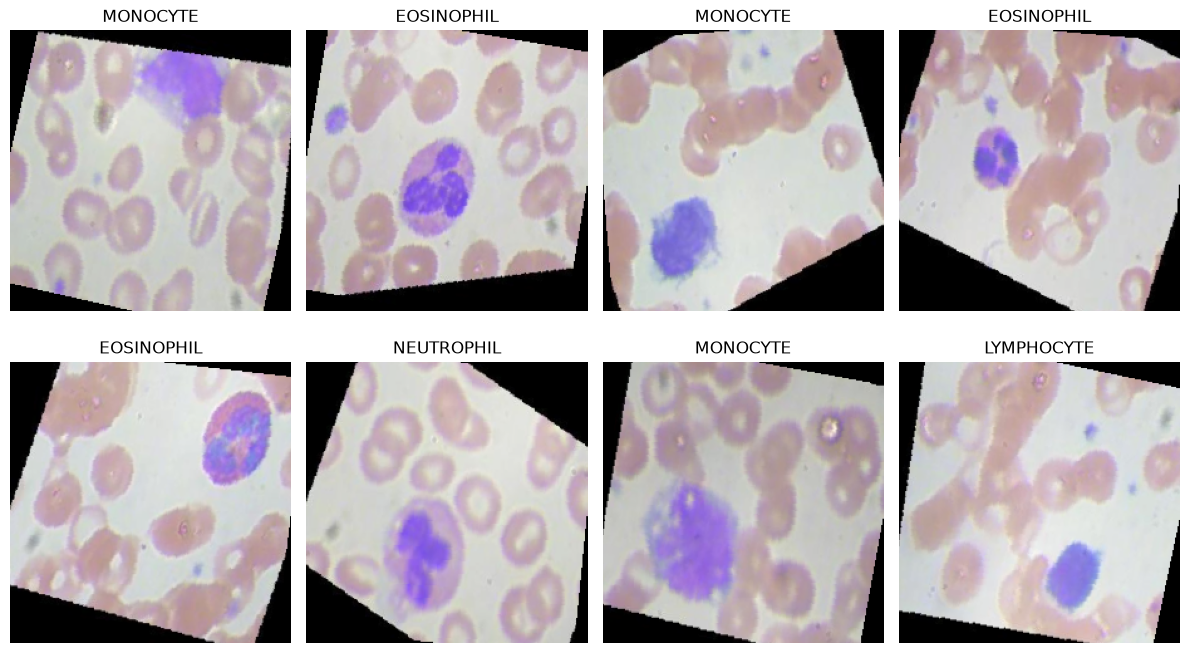

In [27]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 7)
)

for i, ax in enumerate(axes.flat):

    image = denormalize(images[i])

    label = labels[i].item()

    ax.imshow(image)

    ax.set_title(
        idx_to_class[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Import EfficientNet

In [28]:
import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

# Load pretrained weights

In [29]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

print("EfficientNet-B0 loaded successfully")

EfficientNet-B0 loaded successfully


# Look at the original classifier

In [30]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


# Replace the classifier

In [31]:
NUM_CLASSES = len(class_names)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


# Freeze the backbone

In [32]:
for param in model.features.parameters():
    param.requires_grad = False

In [33]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,012,672
Trainable parameters: 5,124


# Move model to GPU

In [34]:
model = model.to(device)

print("Model device:")
print(next(model.parameters()).device)

Model device:
cuda:0


# Define loss function

In [35]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


# Define optimizer

In [36]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

# Add learning-rate scheduler

In [37]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# Test a forward pass

In [38]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape:")
print(images.shape)

print("\nOutput shape:")
print(outputs.shape)

print("\nLabels shape:")
print(labels.shape)

Input shape:
torch.Size([32, 3, 224, 224])

Output shape:
torch.Size([32, 4])

Labels shape:
torch.Size([32])


# Inspect one prediction

In [39]:
probabilities = torch.softmax(
    outputs,
    dim=1
)

predictions = torch.argmax(
    probabilities,
    dim=1
)

print("Predicted indices:")
print(predictions[:10])

print("\nActual indices:")
print(labels[:10])

Predicted indices:
tensor([2, 2, 3, 3, 2, 2, 3, 1, 0, 3], device='cuda:0')

Actual indices:
tensor([1, 0, 0, 3, 1, 0, 2, 0, 0, 3], device='cuda:0')


# Convert prediction to class name

In [40]:
sample_prediction = predictions[0].item()
sample_actual = labels[0].item()

print(
    "Predicted:",
    idx_to_class[sample_prediction]
)

print(
    "Actual:",
    idx_to_class[sample_actual]
)

Predicted: MONOCYTE
Actual: LYMPHOCYTE


# Verify probability sum

In [41]:
print(
    probabilities[0]
)

print(
    "Probability sum:",
    probabilities[0].sum().item()
)

tensor([0.2509, 0.2437, 0.2567, 0.2487], device='cuda:0')
Probability sum: 1.0


# Create a place to save the best model

In [42]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "efficientnet_b0_stage1_best.pth"

print(BEST_MODEL_PATH)

..\models\efficientnet_b0_stage1_best.pth


# Prepare history tracking

In [43]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

# Training function

In [44]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Backbone is frozen during Stage 1.
    # Keep its BatchNorm layers in evaluation mode.
    model.features.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predictions = torch.max(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Validation function

In [45]:
def validate(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predictions = torch.max(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Set training configuration

In [46]:
NUM_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 3

# Train

In [47]:
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{NUM_EPOCHS}"
    )

    print("-" * 50)

    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc = validate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_acc
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Accuracy:   {val_acc:.4f}"
    )

    # Update scheduler
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        epochs_without_improvement = 0

        checkpoint = {
            "architecture": "efficientnet_b0",
            "stage": 1,
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_to_idx": train_full_dataset.class_to_idx,
            "image_size": IMG_SIZE,
            "val_loss": val_loss,
            "val_accuracy": val_acc
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        print(
            "✓ Best model saved"
        )

    else:

        epochs_without_improvement += 1

        print(
            "No validation improvement."
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


Epoch 1/5
--------------------------------------------------


Train Loss: 0.9071 | Train Accuracy: 0.6562
Val Loss:   0.6870 | Val Accuracy:   0.7905
✓ Best model saved

Epoch 2/5
--------------------------------------------------
Train Loss: 0.6093 | Train Accuracy: 0.7924
Val Loss:   0.5764 | Val Accuracy:   0.8313
✓ Best model saved

Epoch 3/5
--------------------------------------------------
Train Loss: 0.5105 | Train Accuracy: 0.8249
Val Loss:   0.4690 | Val Accuracy:   0.8487
✓ Best model saved

Epoch 4/5
--------------------------------------------------
Train Loss: 0.4523 | Train Accuracy: 0.8426
Val Loss:   0.4261 | Val Accuracy:   0.8802
✓ Best model saved

Epoch 5/5
--------------------------------------------------
Train Loss: 0.4190 | Train Accuracy: 0.8566
Val Loss:   0.3979 | Val Accuracy:   0.8835
✓ Best model saved


# Plot Stage-1 curves

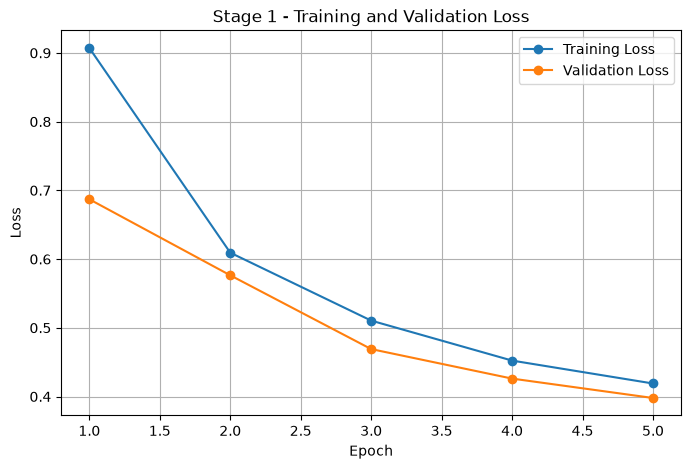

In [48]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 - Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

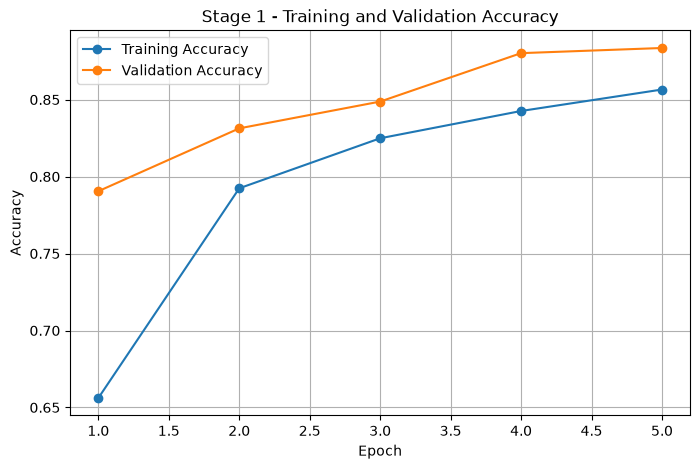

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1 - Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# Check saved checkpoint

In [50]:
print(
    "Model exists:",
    BEST_MODEL_PATH.exists()
)

print(
    "Model size:",
    round(
        BEST_MODEL_PATH.stat().st_size
        / (1024 ** 2),
        2
    ),
    "MB"
)

Model exists: True
Model size: 15.64 MB


Load the best Stage-1 model

In [51]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

print(
    "Loaded Stage 1 model from epoch:",
    checkpoint["epoch"]
)

print(
    "Validation accuracy:",
    checkpoint["val_accuracy"]
)

Loaded Stage 1 model from epoch: 5
Validation accuracy: 0.8835341365461847


Freeze everything

In [52]:
for param in model.parameters():
    param.requires_grad = False

In [53]:
for param in model.classifier.parameters():
    param.requires_grad = True

In [54]:
for param in model.features[-2:].parameters():
    param.requires_grad = True

Check trainable parameters

In [55]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.2f}%"
)

Total parameters:     4,012,672
Trainable parameters: 1,134,516
Trainable percentage: 28.27%


# change to the training function

In [56]:
def train_one_epoch_finetune(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

Use different learning rates:

In [57]:
optimizer_ft = torch.optim.AdamW(
    [
        {
            "params": model.features[-2:].parameters(),
            "lr": 1e-4
        },
        {
            "params": model.classifier.parameters(),
            "lr": 3e-4
        }
    ],
    weight_decay=1e-4
)

Scheduler

In [58]:
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="min",
    factor=0.5,
    patience=2
)

Stage-2 history

In [59]:
history_stage2 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

Model output path

In [60]:
STAGE2_MODEL_PATH = (
    MODEL_DIR /
    "efficientnet_b0_finetuned_best.pth"
)

print(STAGE2_MODEL_PATH)

..\models\efficientnet_b0_finetuned_best.pth


Fine-tune for 5 epochs

In [61]:
FINETUNE_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 3

best_val_loss_ft = float("inf")
epochs_without_improvement = 0

In [63]:
for epoch in range(FINETUNE_EPOCHS):

    print(
        f"\nFine-tuning Epoch "
        f"{epoch + 1}/{FINETUNE_EPOCHS}"
    )

    print("-" * 55)

    train_loss, train_acc = train_one_epoch_finetune(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer_ft,
        device=device
    )

    val_loss, val_acc = validate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history_stage2["train_loss"].append(
        train_loss
    )

    history_stage2["train_accuracy"].append(
        train_acc
    )

    history_stage2["val_loss"].append(
        val_loss
    )

    history_stage2["val_accuracy"].append(
        val_acc
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Accuracy:   {val_acc:.4f}"
    )

    scheduler_ft.step(val_loss)

    if val_loss < best_val_loss_ft:

        best_val_loss_ft = val_loss
        epochs_without_improvement = 0

        checkpoint = {
            "architecture": "efficientnet_b0",
            "stage": 2,
            "epoch": epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer_ft.state_dict(),

            "class_to_idx":
                train_full_dataset.class_to_idx,

            "image_size": IMG_SIZE,

            "val_loss": val_loss,
            "val_accuracy": val_acc
        }

        torch.save(
            checkpoint,
            STAGE2_MODEL_PATH
        )

        print("✓ Best fine-tuned model saved")

    else:

        epochs_without_improvement += 1

        print(
            "No validation-loss improvement."
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


Fine-tuning Epoch 1/5
-------------------------------------------------------
Train Loss: 0.1006 | Train Accuracy: 0.9653
Val Loss:   0.0478 | Val Accuracy:   0.9853
✓ Best fine-tuned model saved

Fine-tuning Epoch 2/5
-------------------------------------------------------
Train Loss: 0.0825 | Train Accuracy: 0.9715
Val Loss:   0.0347 | Val Accuracy:   0.9926
✓ Best fine-tuned model saved

Fine-tuning Epoch 3/5
-------------------------------------------------------
Train Loss: 0.0713 | Train Accuracy: 0.9758
Val Loss:   0.0321 | Val Accuracy:   0.9920
✓ Best fine-tuned model saved

Fine-tuning Epoch 4/5
-------------------------------------------------------
Train Loss: 0.0663 | Train Accuracy: 0.9767
Val Loss:   0.0285 | Val Accuracy:   0.9933
✓ Best fine-tuned model saved

Fine-tuning Epoch 5/5
-------------------------------------------------------
Train Loss: 0.0548 | Train Accuracy: 0.9819
Val Loss:   0.0213 | Val Accuracy:   0.9940
✓ Best fine-tuned model saved


Plot the fine-tuning curves

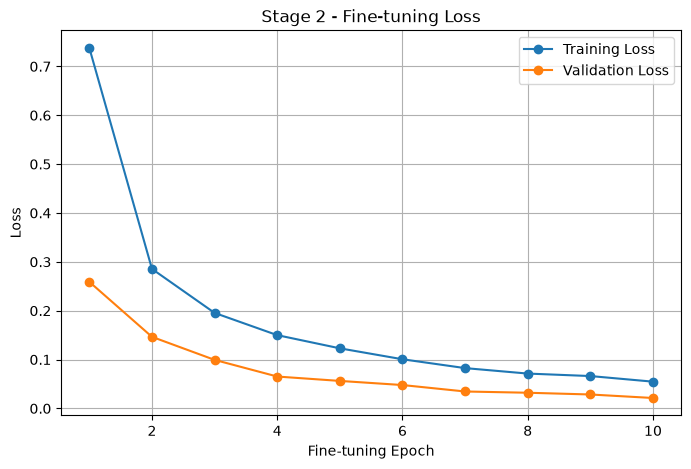

In [64]:
epochs_ft = range(
    1,
    len(history_stage2["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ft,
    history_stage2["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_ft,
    history_stage2["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Fine-tuning Epoch")
plt.ylabel("Loss")
plt.title("Stage 2 - Fine-tuning Loss")
plt.legend()
plt.grid()
plt.show()

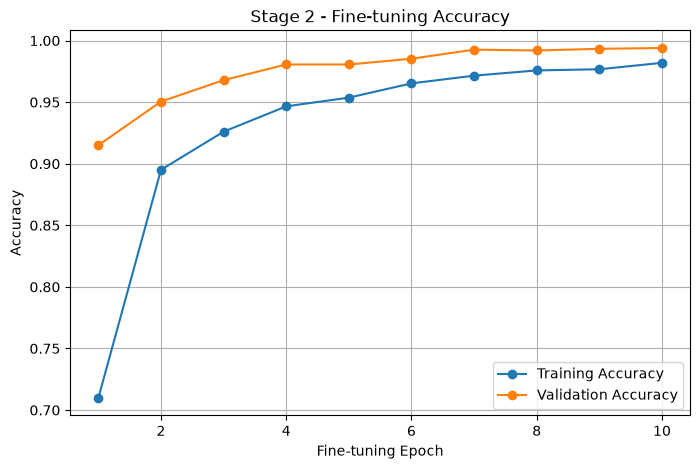

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ft,
    history_stage2["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_ft,
    history_stage2["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Fine-tuning Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 2 - Fine-tuning Accuracy")
plt.legend()
plt.grid()
plt.show()

Load the best fine-tuned checkpoint

In [66]:
checkpoint = torch.load(
    STAGE2_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Loaded checkpoint:")
print("Epoch:", checkpoint["epoch"])
print("Validation accuracy:", checkpoint["val_accuracy"])
print("Validation loss:", checkpoint["val_loss"])

Loaded checkpoint:
Epoch: 5
Validation accuracy: 0.9939759036144579
Validation loss: 0.02133351072190277


Evaluate the untouched test set

In [67]:
all_labels = []
all_predictions = []
all_probabilities = []

test_running_loss = 0.0
test_total = 0

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        test_running_loss += (
            loss.item() * images.size(0)
        )

        test_total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

test_loss = (
    test_running_loss / test_total
)

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("Finished test evaluation.")
print("Test images:", len(all_labels))
print("Test loss:", test_loss)

Finished test evaluation.
Test images: 2487
Test loss: 1.0951383747295247


Accuracy, precision, recall and F1

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Test Loss:       {test_loss:.4f}")
print(f"Test Accuracy:   {test_accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1-score:  {macro_f1:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")

Test Loss:       1.0951
Test Accuracy:   0.8158
Macro Precision: 0.8524
Macro Recall:    0.8158
Macro F1-score:  0.8176
Weighted F1:     0.8175


Classification report

In [69]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

  EOSINOPHIL     0.8062    0.7881    0.7971       623
  LYMPHOCYTE     0.9935    0.9806    0.9870       620
    MONOCYTE     0.9844    0.6113    0.7542       620
  NEUTROPHIL     0.6254    0.8830    0.7322       624

    accuracy                         0.8158      2487
   macro avg     0.8524    0.8158    0.8176      2487
weighted avg     0.8520    0.8158    0.8175      2487



Save the classification report

In [70]:
RESULTS_DIR = Path("../results")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [71]:
with open(
    RESULTS_DIR / "classification_report.txt",
    "w"
) as f:

    f.write(report)

print("Classification report saved.")

Classification report saved.


Generate confusion matrix

In [72]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[491   3   1 128]
 [  2 608   3   7]
 [ 46   0 379 195]
 [ 70   1   2 551]]


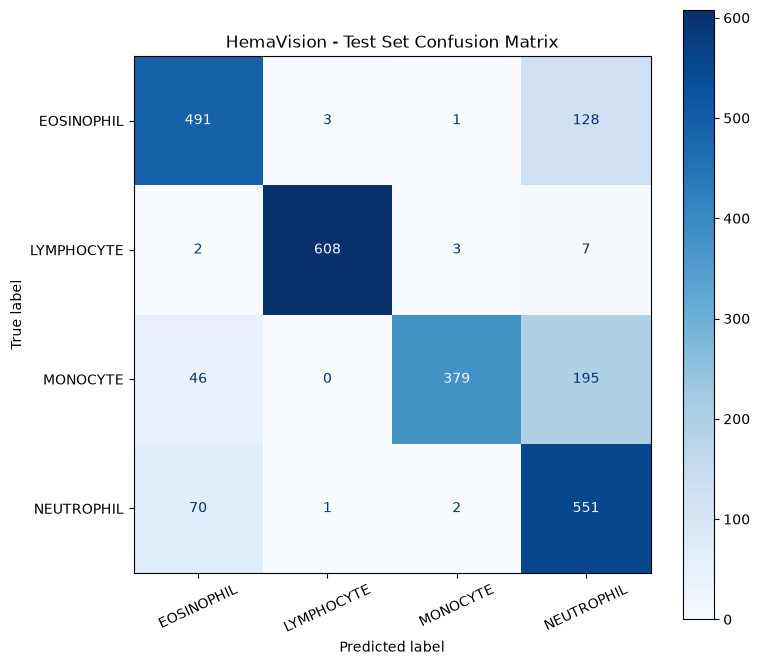

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(8, 7)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "HemaVision - Test Set Confusion Matrix"
)

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save metrics as JSON

In [74]:
import json

metrics = {
    "test_images": int(len(all_labels)),
    "test_loss": float(test_loss),
    "accuracy": float(test_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1)
}

with open(
    RESULTS_DIR / "metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print(metrics)

{'test_images': 2487, 'test_loss': 1.0951383747295247, 'accuracy': 0.8158423803779654, 'macro_precision': 0.8523862566612024, 'macro_recall': 0.8157675736882424, 'macro_f1': 0.8176364196083912, 'weighted_f1': 0.8174742493162561}


Create a test-predictions CSV

In [75]:
test_paths = [
    path
    for path, _ in test_dataset.samples
]

true_names = [
    idx_to_class[label]
    for label in all_labels
]

predicted_names = [
    idx_to_class[pred]
    for pred in all_predictions
]

confidence_scores = (
    all_probabilities.max(axis=1)
)

prediction_df = pd.DataFrame({
    "image_path": test_paths,
    "ground_truth": true_names,
    "prediction": predicted_names,
    "confidence": confidence_scores,
    "correct": (
        all_labels == all_predictions
    )
})

prediction_df.head()

,image_path,ground_truth,prediction,confidence,correct
0,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.554730,False
1,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.573048,False
2,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,EOSINOPHIL,0.944291,True
3,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.980270,False
4,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,EOSINOPHIL,0.941362,True


In [76]:
prediction_df.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False
)

Quick error analysis

In [77]:
print(
    "Correct predictions:",
    prediction_df["correct"].sum()
)

print(
    "Incorrect predictions:",
    (~prediction_df["correct"]).sum()
)

Correct predictions: 2029
Incorrect predictions: 458


In [78]:
prediction_df[
    prediction_df["correct"] == False
].head(20)

,image_path,ground_truth,prediction,confidence,correct
0,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.554730,False
1,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.573048,False
3,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.980270,False
12,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.478611,False
19,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.854703,False
20,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.841946,False
22,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.999333,False
23,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.788795,False
35,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.998142,False
40,..\data\raw\dataset2-master\dataset2-master\im...,EOSINOPHIL,NEUTROPHIL,0.838063,False


## Corrected Group-Aware Train/Validation Split

The original random image-level validation split may contain augmented
variants from the same source image in both training and validation sets.
A group-aware split is therefore used to keep all augmented variants
belonging to the same source group in a single partition.

In [79]:
import re
import numpy as np
from collections import defaultdict
from torchvision.datasets import ImageFolder

In [80]:
def extract_group(filename):
    """
    Example:
    _10_1234.jpeg -> 10
    _3_5678.jpeg  -> 3
    """
    match = re.match(
        r"_(\d+)_",
        filename
    )

    if match:
        return match.group(1)

    raise ValueError(
        f"Could not extract group from: {filename}"
    )

Build grouped indices

In [81]:
base_train_dataset = ImageFolder(
    root=TRAIN_DIR
)

rng = np.random.RandomState(SEED)

class_group_indices = defaultdict(
    lambda: defaultdict(list)
)

for index, (path, class_idx) in enumerate(
    base_train_dataset.samples
):

    filename = Path(path).name

    group = extract_group(
        filename
    )

    # Combine class and group because
    # group number "0" can occur in several classes.
    group_key = (
        f"{class_idx}_{group}"
    )

    class_group_indices[class_idx][
        group_key
    ].append(index)

In [82]:
train_indices_grouped = []
val_indices_grouped = []

VAL_GROUP_RATIO = 0.20

for class_idx, groups_dict in (
    class_group_indices.items()
):

    groups = list(
        groups_dict.keys()
    )

    rng.shuffle(groups)

    num_val_groups = max(
        1,
        round(
            len(groups)
            * VAL_GROUP_RATIO
        )
    )

    val_groups = set(
        groups[:num_val_groups]
    )

    train_groups = set(
        groups[num_val_groups:]
    )

    for group in train_groups:

        train_indices_grouped.extend(
            groups_dict[group]
        )

    for group in val_groups:

        val_indices_grouped.extend(
            groups_dict[group]
        )

Check the new size

In [83]:
print(
    "Grouped Train images:",
    len(train_indices_grouped)
)

print(
    "Grouped Validation images:",
    len(val_indices_grouped)
)

print(
    "Total:",
    len(train_indices_grouped)
    +
    len(val_indices_grouped)
)

Grouped Train images: 8026
Grouped Validation images: 1931
Total: 9957


Verify zero group leakage

In [84]:
def get_groups_from_indices(
    dataset,
    indices
):

    groups = set()

    for index in indices:

        path, class_idx = (
            dataset.samples[index]
        )

        filename = Path(path).name

        group = extract_group(
            filename
        )

        groups.add(
            f"{class_idx}_{group}"
        )

    return groups

In [85]:
train_groups_check = get_groups_from_indices(
    base_train_dataset,
    train_indices_grouped
)

val_groups_check = get_groups_from_indices(
    base_train_dataset,
    val_indices_grouped
)

overlap = (
    train_groups_check
    &
    val_groups_check
)

print(
    "Train source groups:",
    len(train_groups_check)
)

print(
    "Validation source groups:",
    len(val_groups_check)
)

print(
    "Overlapping groups:",
    len(overlap)
)

Train source groups: 222
Validation source groups: 55
Overlapping groups: 0


Check class distributions

In [86]:
targets = np.array(
    base_train_dataset.targets
)

train_group_labels = targets[
    train_indices_grouped
]

val_group_labels = targets[
    val_indices_grouped
]

from collections import Counter

print("TRAIN")

for label, count in sorted(
    Counter(
        train_group_labels
    ).items()
):

    print(
        idx_to_class[label],
        count
    )


print("\nVALIDATION")

for label, count in sorted(
    Counter(
        val_group_labels
    ).items()
):

    print(
        idx_to_class[label],
        count
    )

TRAIN
EOSINOPHIL 1997
LYMPHOCYTE 2021
MONOCYTE 2013
NEUTROPHIL 1995

VALIDATION
EOSINOPHIL 500
LYMPHOCYTE 462
MONOCYTE 465
NEUTROPHIL 504


Create corrected datasets

In [87]:
train_full_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_full_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=val_test_transform
)

In [88]:
train_dataset = Subset(
    train_full_dataset,
    train_indices_grouped
)

val_dataset = Subset(
    val_full_dataset,
    val_indices_grouped
)

In [89]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Create a completely fresh model:

In [90]:
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

In [91]:
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print("Group overlap:", len(overlap))

Train images: 8026
Validation images: 1931
Test images: 2487
Group overlap: 0


Create a completely fresh EfficientNet-B0

In [92]:
import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

NUM_CLASSES = 4

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)

model = model.to(device)

print("Device:", device)
print(model.classifier)

Device: cuda
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


Stage 1 — Train only the classifier

In [93]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [94]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 4012672
Trainable parameters: 5124


In [95]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [96]:
def train_one_epoch_stage1(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Backbone is frozen.
    # Keep BatchNorm layers fixed too.
    model.features.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )

In [97]:
def validate(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )

In [98]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

GROUP_STAGE1_PATH = (
    MODEL_DIR /
    "efficientnet_b0_groupaware_stage1.pth"
)

In [99]:
STAGE1_EPOCHS = 5

history_stage1_group = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")

for epoch in range(STAGE1_EPOCHS):

    print(
        f"\nStage 1 Epoch "
        f"{epoch + 1}/{STAGE1_EPOCHS}"
    )

    print("-" * 55)

    train_loss, train_acc = train_one_epoch_stage1(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history_stage1_group[
        "train_loss"
    ].append(train_loss)

    history_stage1_group[
        "train_accuracy"
    ].append(train_acc)

    history_stage1_group[
        "val_loss"
    ].append(val_loss)

    history_stage1_group[
        "val_accuracy"
    ].append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Accuracy:   {val_acc:.4f}"
    )

    scheduler.step(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "architecture": "efficientnet_b0",
                "stage": 1,
                "model_state_dict":
                    model.state_dict(),
                "class_to_idx":
                    train_full_dataset.class_to_idx,
                "image_size": IMG_SIZE,
                "val_loss": val_loss,
                "val_accuracy": val_acc
            },
            GROUP_STAGE1_PATH
        )

        print("✓ Best Stage-1 model saved")


Stage 1 Epoch 1/5
-------------------------------------------------------
Train Loss: 0.9366 | Train Accuracy: 0.6443
Val Loss:   0.7443 | Val Accuracy:   0.7582
✓ Best Stage-1 model saved

Stage 1 Epoch 2/5
-------------------------------------------------------
Train Loss: 0.6458 | Train Accuracy: 0.7730
Val Loss:   0.5959 | Val Accuracy:   0.8089
✓ Best Stage-1 model saved

Stage 1 Epoch 3/5
-------------------------------------------------------
Train Loss: 0.5466 | Train Accuracy: 0.8158
Val Loss:   0.5259 | Val Accuracy:   0.8457
✓ Best Stage-1 model saved

Stage 1 Epoch 4/5
-------------------------------------------------------
Train Loss: 0.4907 | Train Accuracy: 0.8238
Val Loss:   0.4782 | Val Accuracy:   0.8534
✓ Best Stage-1 model saved

Stage 1 Epoch 5/5
-------------------------------------------------------
Train Loss: 0.4479 | Train Accuracy: 0.8439
Val Loss:   0.4489 | Val Accuracy:   0.8555
✓ Best Stage-1 model saved


Stage 2 — Fine-tune EfficientNet

In [100]:
checkpoint = torch.load(
    GROUP_STAGE1_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

print(
    "Loaded Stage-1 epoch:",
    checkpoint["epoch"]
)

print(
    "Stage-1 validation accuracy:",
    checkpoint["val_accuracy"]
)

Loaded Stage-1 epoch: 5
Stage-1 validation accuracy: 0.8555152770585189


In [101]:
for param in model.parameters():
    param.requires_grad = False

In [102]:
for param in model.features[-2:].parameters():
    param.requires_grad = True

In [103]:
for param in model.classifier.parameters():
    param.requires_grad = True

In [104]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Fine-tuning trainable parameters:",
    trainable_params
)

Fine-tuning trainable parameters: 1134516


In [105]:
optimizer_ft = torch.optim.AdamW(
    [
        {
            "params":
                model.features[-2:].parameters(),
            "lr": 1e-4
        },
        {
            "params":
                model.classifier.parameters(),
            "lr": 3e-4
        }
    ],
    weight_decay=1e-4
)

scheduler_ft = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_ft,
        mode="min",
        factor=0.5,
        patience=2
    )
)

In [106]:
def train_one_epoch_finetune(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )

Fine-tune for five epochs

In [107]:
GROUP_STAGE2_PATH = (
    MODEL_DIR /
    "efficientnet_b0_groupaware_finetuned_best.pth"
)

In [108]:
history_stage2_group = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss_ft = float("inf")

In [109]:
FINETUNE_EPOCHS = 5

for epoch in range(FINETUNE_EPOCHS):

    print(
        f"\nFine-tuning Epoch "
        f"{epoch + 1}/{FINETUNE_EPOCHS}"
    )

    print("-" * 55)

    train_loss, train_acc = (
        train_one_epoch_finetune(
            model,
            train_loader,
            criterion,
            optimizer_ft,
            device
        )
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history_stage2_group[
        "train_loss"
    ].append(train_loss)

    history_stage2_group[
        "train_accuracy"
    ].append(train_acc)

    history_stage2_group[
        "val_loss"
    ].append(val_loss)

    history_stage2_group[
        "val_accuracy"
    ].append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Accuracy:   {val_acc:.4f}"
    )

    scheduler_ft.step(val_loss)

    if val_loss < best_val_loss_ft:

        best_val_loss_ft = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "architecture":
                    "efficientnet_b0",
                "stage": 2,

                "model_state_dict":
                    model.state_dict(),

                "class_to_idx":
                    train_full_dataset.class_to_idx,

                "image_size":
                    IMG_SIZE,

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_acc
            },
            GROUP_STAGE2_PATH
        )

        print(
            "✓ Best group-aware "
            "fine-tuned model saved"
        )


Fine-tuning Epoch 1/5
-------------------------------------------------------
Train Loss: 0.7614 | Train Accuracy: 0.7008
Val Loss:   0.3085 | Val Accuracy:   0.8881
✓ Best group-aware fine-tuned model saved

Fine-tuning Epoch 2/5
-------------------------------------------------------
Train Loss: 0.3028 | Train Accuracy: 0.8871
Val Loss:   0.1670 | Val Accuracy:   0.9415
✓ Best group-aware fine-tuned model saved

Fine-tuning Epoch 3/5
-------------------------------------------------------
Train Loss: 0.1921 | Train Accuracy: 0.9308
Val Loss:   0.1178 | Val Accuracy:   0.9560
✓ Best group-aware fine-tuned model saved

Fine-tuning Epoch 4/5
-------------------------------------------------------
Train Loss: 0.1537 | Train Accuracy: 0.9436
Val Loss:   0.0989 | Val Accuracy:   0.9643
✓ Best group-aware fine-tuned model saved

Fine-tuning Epoch 5/5
-------------------------------------------------------
Train Loss: 0.1190 | Train Accuracy: 0.9584
Val Loss:   0.0660 | Val Accuracy:   0.97

Load the corrected best model

In [110]:
checkpoint = torch.load(
    GROUP_STAGE2_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print(
    "Group-aware validation accuracy:",
    checkpoint["val_accuracy"]
)

Loaded epoch: 5
Group-aware validation accuracy: 0.9777317452097359


Evaluate the official test set

In [111]:
all_labels_new = []
all_predictions_new = []
all_probabilities_new = []

test_running_loss_new = 0.0
test_total_new = 0

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        test_running_loss_new += (
            loss.item() * images.size(0)
        )

        test_total_new += labels.size(0)

        all_labels_new.extend(
            labels.cpu().numpy()
        )

        all_predictions_new.extend(
            predictions.cpu().numpy()
        )

        all_probabilities_new.extend(
            probabilities.cpu().numpy()
        )

In [113]:
all_labels_new = np.array(
    all_labels_new
)

all_predictions_new = np.array(
    all_predictions_new
)

all_probabilities_new = np.array(
    all_probabilities_new
)

test_loss_new = (
    test_running_loss_new /
    test_total_new
)

In [114]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_accuracy_new = accuracy_score(
    all_labels_new,
    all_predictions_new
)

macro_precision_new = precision_score(
    all_labels_new,
    all_predictions_new,
    average="macro"
)

macro_recall_new = recall_score(
    all_labels_new,
    all_predictions_new,
    average="macro"
)

macro_f1_new = f1_score(
    all_labels_new,
    all_predictions_new,
    average="macro"
)

weighted_f1_new = f1_score(
    all_labels_new,
    all_predictions_new,
    average="weighted"
)

print(
    f"Test Loss:       {test_loss_new:.4f}"
)

print(
    f"Test Accuracy:   {test_accuracy_new:.4f}"
)

print(
    f"Macro Precision: {macro_precision_new:.4f}"
)

print(
    f"Macro Recall:    {macro_recall_new:.4f}"
)

print(
    f"Macro F1-score:  {macro_f1_new:.4f}"
)

print(
    f"Weighted F1:     {weighted_f1_new:.4f}"
)

Test Loss:       0.9044
Test Accuracy:   0.7933
Macro Precision: 0.8301
Macro Recall:    0.7932
Macro F1-score:  0.7970
Weighted F1:     0.7968


In [115]:
from sklearn.metrics import classification_report

report_new = classification_report(
    all_labels_new,
    all_predictions_new,
    target_names=test_dataset.classes,
    digits=4
)

print(report_new)

              precision    recall  f1-score   support

  EOSINOPHIL     0.7285    0.8010    0.7630       623
  LYMPHOCYTE     0.9947    0.9016    0.9459       620
    MONOCYTE     0.9673    0.6194    0.7552       620
  NEUTROPHIL     0.6299    0.8510    0.7239       624

    accuracy                         0.7933      2487
   macro avg     0.8301    0.7932    0.7970      2487
weighted avg     0.8296    0.7933    0.7968      2487



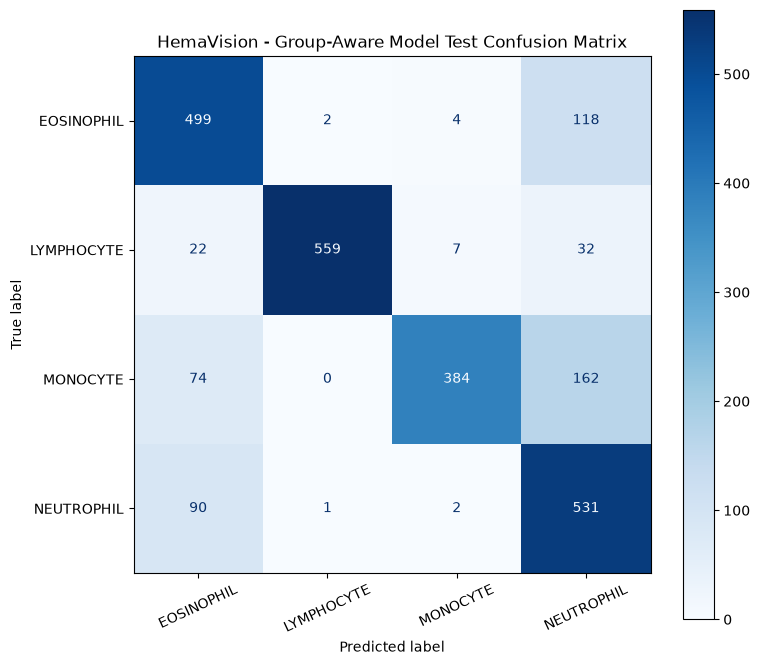

In [116]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm_new = confusion_matrix(
    all_labels_new,
    all_predictions_new
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm_new,
    display_labels=test_dataset.classes
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "HemaVision - Group-Aware Model Test Confusion Matrix"
)

plt.xticks(rotation=25)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "groupaware_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [117]:
import json

final_metrics = {
    "test_images":
        int(len(all_labels_new)),

    "test_loss":
        float(test_loss_new),

    "accuracy":
        float(test_accuracy_new),

    "macro_precision":
        float(macro_precision_new),

    "macro_recall":
        float(macro_recall_new),

    "macro_f1":
        float(macro_f1_new),

    "weighted_f1":
        float(weighted_f1_new),

    "validation_accuracy":
        float(checkpoint["val_accuracy"]),

    "split_method":
        "group-aware train-validation split"
}

with open(
    RESULTS_DIR /
    "groupaware_metrics.json",
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

In [118]:
with open(
    RESULTS_DIR /
    "groupaware_classification_report.txt",
    "w"
) as f:

    f.write(report_new)